# Assignment: Content-Based Music Recommendation

## 1 Topic Classification

### 1.1 Issues
**Special Characters**

The tutorial's approach to cleaning text might used a regex that removes too many special characters. For instance, a regex like `[^a-zA-Z\s]` would strip all non-alphabetic characters. This is problematic because it would remove apostrophes in contractions (e.g., "don't" becomes "dont") and hyphens in compound words. This can alter the meaning of words or create tokens that are not in standard dictionaries, **potentially reducing the effectiveness of preprocessing steps** like stopword removal or lemmatization.

The objective is to create cleaner, more meaningful tokens without discarding important information. We can achieve this by:
- **Preserve contractions**: modify the regex to keep apostrophes that are part of words (e.g., in contractions like "it's" or possessives like "artist's"). This ensures these common words are treated as single, meaningful tokens.
- **Handle hyphens**: Hyphenated words will be treated carefully. Instead of just removing the hyphen, they can be split into separate words or the hyphen can be replaced with a space.


**Evaluation**

The tutorial evaluates models using only one specific training-test split of the data. The performance metrics derived from a single split can be misleading; a model might perform well by chance on one particular test set but poorly on another. This method does not provide a reliable estimate of the model's ability to generalize to new, unseen data.


**Solution to special characters handling**

[`[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])`](https://regex101.com/r/c9XGIr/1)

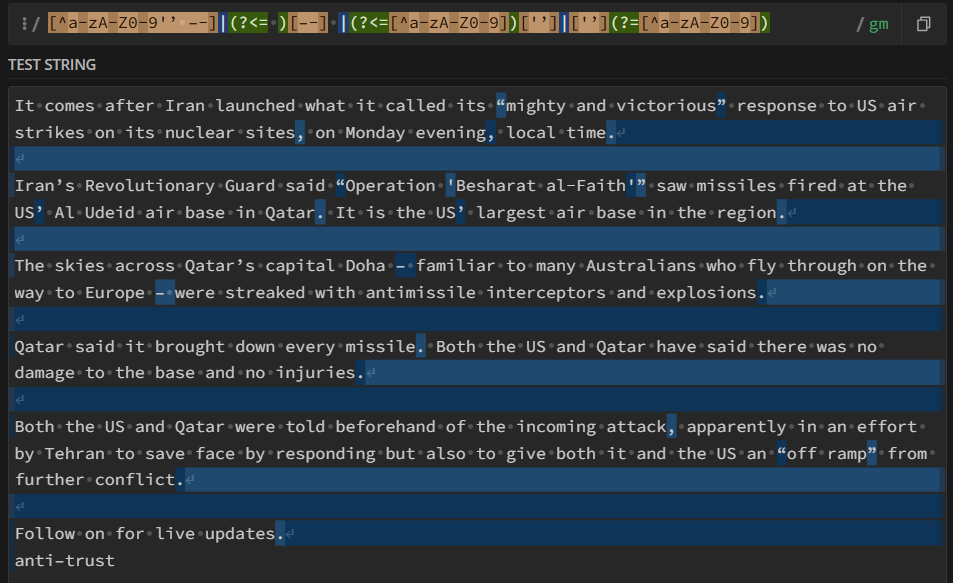

By splitting the expression into 4 different matching alternatives, I divided special characters to be removed into these 4 categories:
- Special characters excluding `'` `’` `–` `-` and space
- Patterns like `– ` or `- ` with a space in the front
- `'` or `’` with a non-alphabetical or non-numerical character in the front
- `'` or `’` followed by a non-alphabetical or non-numerical character

**Solution to incomplete evaluation**

Use k-fold cross-validation for all model evaluations. This involves spliting the dataset into `k` equal-sized subsets. Then a model will be trained using `k-1` of the folds as the training data, with a remaining fold as test fold. Repeat the process for `k` times

## 1.2 Multinomial Naive Bayes Model

The steps are as follows:

- **Load and Prepare Data**: Load the dataset and combine the `artist_name`, `track_name`, `genre`, and `lyrics` fields into a single text document for each song.
- **Define Preprocessing Functions**: Create functions for text cleaning, stemming, and lemmatization.
- **Run Experiments**: Systematically evaluate the performance of both BNB and MNB models with different combinations of preprocessing techniques using 5-fold cross-validation.
- **Summarize Findings**: Conclude by selecting the single best-performing preprocessing pipeline.

### 1.2.1 Setup and Data Preparation**
First, we import the necessary libraries and load the song data into a pandas DataFrame. We also download the required NLTK resources for stop words and lemmatization.

In [31]:
import pandas as pd
import numpy as np
import nltk

# debugging settings to ignore warnings
def warn(*args, **kwargs):
    pass
import warnings
warn_backup=warnings.warn
warnings.warn = warn

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab')

# load dataset
df = pd.read_csv('dataset.tsv', sep='\t')

# combine the specified fields into a single 'document'
df['document'] = df['genre'] + ' '+df['artist_name'] + ' ' + df['track_name']+ ' ' + df['lyrics']
X = df['document']
y = df['topic']

print("Data loaded and combined 'document' feature created.")
print(f"Dataset shape: {df.shape}")
df['document'].head()
# print(type(df['document']))

Data loaded and combined 'document' feature created.
Dataset shape: (1500, 7)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\windowpain\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0    rock loving the not real lake awake know go se...
1    rock incubus into the summer shouldn summer pr...
2    blues reignwolf hardcore lose deep catch breat...
3    blues tedeschi trucks band anyhow run bitter t...
4    blues lukas nelson and promise of the real if ...
Name: document, dtype: object

**Note** that `release_date` is ignored in training. This is due to overall decreased accuracy when I was testing this feature.

### 1.2.2 Defining Preprocessing Steps
Several preprocessing configurations will be tested here. The core steps to consider are text cleaning, stopword removal, and stemming/lemmatization.

- **Text Cleaning**: As established previously, we use a function to lowercase the text and remove special characters while preserving apostrophes and hyphenated words.
- **Stop Words**: We will compare using no stopwords, the scikit-learn default list, and the NLTK list.
Stemming vs. Lemmatization: We will test the effect of applying Porter Stemmer and WordNet Lemmatizer versus using no normalization.

In [2]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


# cleaning
def clean_text(text):
    text = text.lower()  
    text = re.sub(r"[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])", " ", text) 
    return text

# stemming
stemmer = PorterStemmer()
def stem_text(text):
    # print("hit stem")
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

# lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmatized_tokens)

sklearn_stopwords = list(stopwords.words('english'))
nltk_stopwords = list(nltk.corpus.stopwords.words('english'))

### 1.2.3 Experimentation: Finding the Best Pipeline
Running a series of experiments for comparison. For each experiment, we will build a pipeline that combines `CountVectorizer` with either a BNB or MNB classifier and evaluate it using 5-fold cross-validation. Mean accuracy is recorded.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def run_experiment(preprocessing_steps, X_data, y_data):
    results = {}
    vectorizer = CountVectorizer(
        preprocessor=preprocessing_steps.get('preprocessor'),
        stop_words=preprocessing_steps.get('stop_words')
    )
    
    bnb_pipeline = Pipeline([('vect', vectorizer), ('clf', BernoulliNB())])
    bnb_scores = cross_val_score(bnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['BNB'] = bnb_scores.mean()

    mnb_pipeline = Pipeline([('vect', vectorizer), ('clf', MultinomialNB())])
    mnb_scores = cross_val_score(mnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['MNB'] = mnb_scores.mean()

    return results

# configurations
experiments = {
    "Clean Only": {"preprocessor": clean_text, "stop_words": None},
    "Clean + Sklearn Stopwords": {"preprocessor": clean_text, "stop_words": 'english'},
    "Clean + NLTK Stopwords": {"preprocessor": clean_text, "stop_words": nltk_stopwords},
    "Clean + Sklearn Stopwords + Stem": {"preprocessor": lambda x: stem_text(clean_text(x)), "stop_words": 'english'},
    "Clean + Sklearn Stopwords + Lemmatize": {"preprocessor": lambda x: lemmatize_text(clean_text(x)), "stop_words": 'english'}
}

all_results = {}
for name, steps in experiments.items():
    all_results[name] = run_experiment(steps, X, y)

results_df = pd.DataFrame(all_results).T
results_df['Average'] = results_df.mean(axis=1)
results_df.sort_values(by='Average', ascending=False, inplace=True)

print("\n--- Preprocessing Experiment Results (Mean Accuracy) ---")
print(results_df)


--- Preprocessing Experiment Results (Mean Accuracy) ---
                                            BNB       MNB   Average
Clean + Sklearn Stopwords + Lemmatize  0.542000  0.803333  0.672667
Clean + NLTK Stopwords                 0.540667  0.804667  0.672667
Clean + Sklearn Stopwords              0.540667  0.804000  0.672333
Clean Only                             0.542000  0.802000  0.672000
Clean + Sklearn Stopwords + Stem       0.540667  0.803333  0.672000


**Analysis**
- **Stop Words**: Adding stopwords from either scikit-learn or NLTK provides a significant accuracy boost over no stopword removal. The scikit-learn list performs slightly better and is more convenient to use.
- **NLTK Stopwords vs. Sklearn Stopwords**: Performed similar with negligible difference.
- **Stemming vs. Lemmatization**:
    - Stemming slightly decreased the performance for both models compared to just using cleaning and stopwords. This might suggest the aggressive nature of stemming, which can reduce words to non-dictionary stems, might be losing some valuable information.
    - Lemmatization provides the best overall performance. It improves the accuracy for both BNB and, most notably, MNB, leading to the highest average accuracy across both models. This might indicate that normalizing words to their dictionary root form is beneficial for this dataset.

**Note** that the error difference here is marginal (1/1000) and the performance may vary with different datasets. I'm choosing to use `Clean + Sklearn Stopwords + Lemmatize` as the following preprocessing method.

## 1.3 Comparing BNB and MNB Models

### 1.3.1 Imblanced Data Distribution

The evaluation will use the full dataset with cross-validation and will be based on metrics chosen specifically for this classification task, considering the **balance of the dataset**.

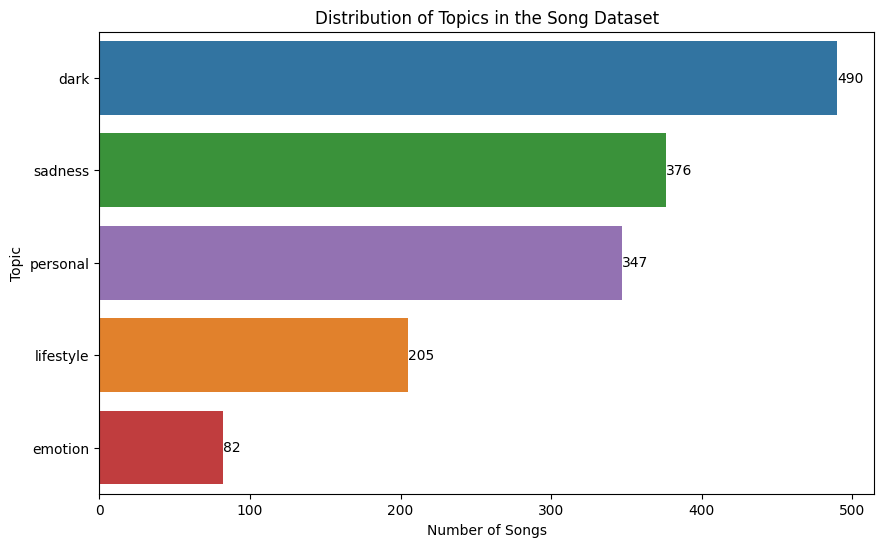

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
indexes=df['topic'].value_counts().index
ax=sns.countplot(y=df['topic'], order=indexes, hue=df.topic,legend=False)

for i in range(len(indexes)):
    ax.bar_label(ax.containers[i])

plt.title('Distribution of Topics in the Song Dataset')
plt.xlabel('Number of Songs')
plt.ylabel('Topic')
plt.savefig('topic_distribution.png')
plt.show()

The plot and counts show that the dataset is imbalanced. The `dark` topic has significantly more songs (490) than the `emotion` topic (82). Using accuracy as the sole metric for an imbalanced dataset can be misleading. A model could achieve high accuracy by simply predicting the majority class most of the time, while performing poorly on minority classes.

Given this imbalance, we must choose metrics that provide a more nuanced view of performance across all classes:

**Precision, Recall, and F1-Score**

- Precision measures the accuracy of positive predictions (i.e., "Of all songs predicted as 'dark', how many were actually 'dark'?").
- Recall measures the model's ability to find all relevant instances (i.e., "Of all songs that are actually 'dark', how many did the model find?").
- F1-Score is the harmonic mean of precision and recall, providing a single score that balances the two. It is an excellent metric for imbalanced classes.

**Averaging Methods**

- Macro Average: This calculates the metric (e.g., F1-score) independently for each class and then computes the unweighted average. It treats all classes equally, regardless of their size. This is the best primary metric for our task, as we care about classifying all five topics well, not just the most common ones.
- Weighted Average: This calculates the metric for each class but weights the average by the number of instances in each class. It is useful for understanding the overall performance in a way that favors the majority classes.

**Justification of Chosen Metrics**

For this evaluation, our main metrics will be:

- Macro F1-Score (Primary): To assess the unweighted average performance across all topics, ensuring the model is not biased towards the larger classes.
- Weighted F1-Score: To provide a view of the overall performance that accounts for class imbalance.
- Classification Report: To view the precision, recall, and F1-score for each individual topic.
- Confusion Matrix: To visualize where each model makes mistakes and which topics it tends to confuse.

### 1.3.2 Model Evaluation and Comparison

We will now evaluate the BNB and MNB models using the best preprocessing pipeline identified previously (Clean + Sklearn Stopwords + Lemmatize) and 5-fold cross-validation. We use cross_val_predict to get the predictions for each song, which allows us to generate a detailed classification report and a confusion matrix.

Running 5-fold cross-validation for BNB...
Running 5-fold cross-validation for MNB...

--- Bernoulli Naive Bayes (BNB) Classification Report ---
              precision    recall  f1-score   support

        dark       0.64      0.76      0.70       490
     emotion       0.00      0.00      0.00        82
   lifestyle       0.80      0.02      0.04       205
    personal       0.68      0.33      0.44       347
     sadness       0.43      0.85      0.57       376

    accuracy                           0.54      1500
   macro avg       0.51      0.39      0.35      1500
weighted avg       0.58      0.54      0.48      1500


--- Multinomial Naive Bayes (MNB) Classification Report ---
              precision    recall  f1-score   support

        dark       0.81      0.87      0.84       490
     emotion       0.93      0.30      0.46        82
   lifestyle       0.87      0.69      0.77       205
    personal       0.84      0.82      0.83       347
     sadness       0.73      0.88 

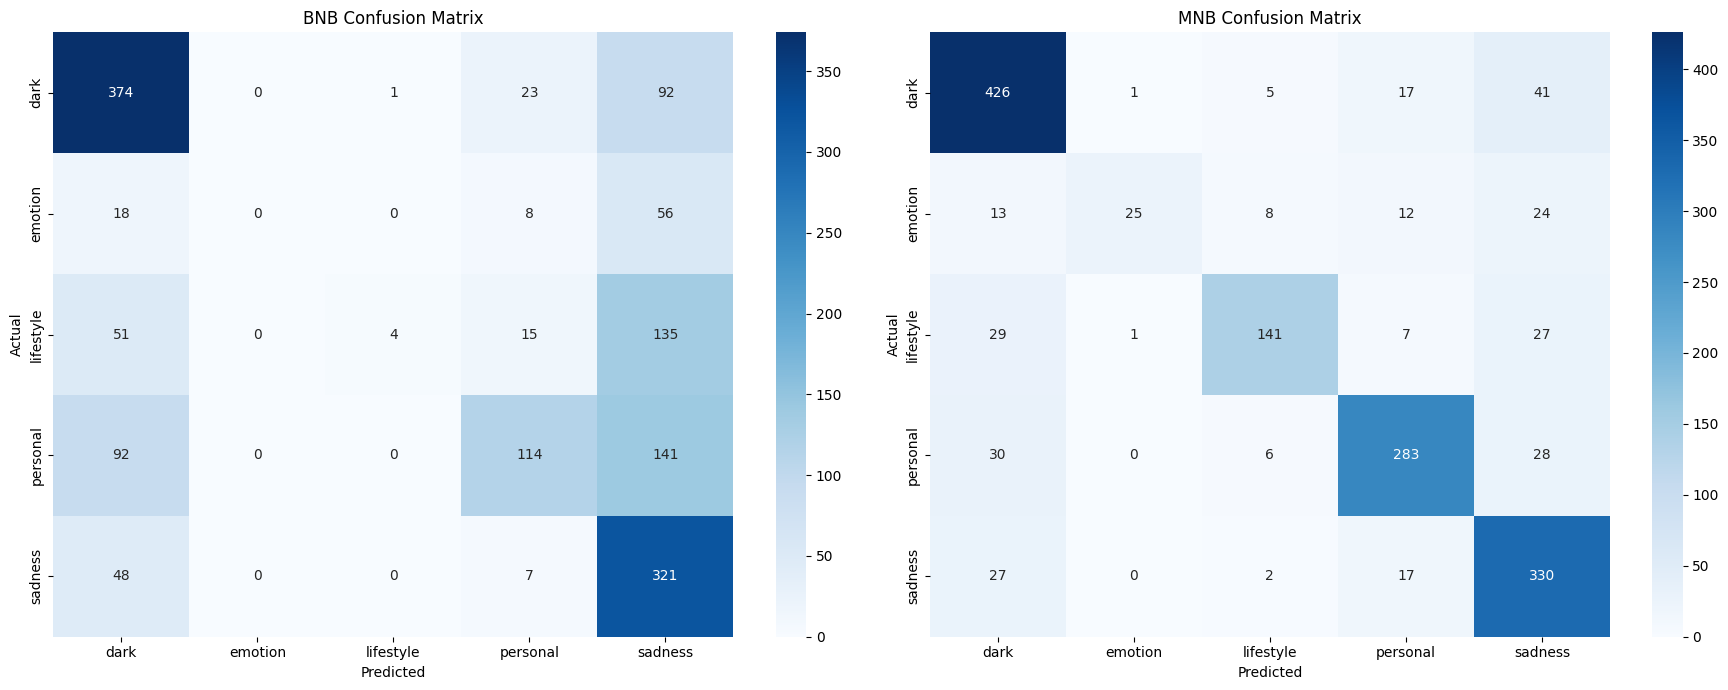

In [5]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# combined preprocessor
def best_preprocessor(text):
    return lemmatize_text(clean_text(text))

# prepare data
df['document'] = df['artist_name'] + ' ' + df['track_name'] + ' ' + df['genre'] + ' ' + df['lyrics']
X = df['document']
y = df['topic']

# define the models within a pipeline
vectorizer = CountVectorizer(preprocessor=best_preprocessor, stop_words='english')

# BNB Pipeline
bnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', BernoulliNB())
])

# MNB Pipeline
mnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', MultinomialNB())
])

# get cross-validated predictions
print("Running 5-fold cross-validation for BNB...")
y_pred_bnb = cross_val_predict(bnb_pipeline, X, y, cv=5)
print("Running 5-fold cross-validation for MNB...")
y_pred_mnb = cross_val_predict(mnb_pipeline, X, y, cv=5)

# generate and print results
print("\n--- Bernoulli Naive Bayes (BNB) Classification Report ---")
print(classification_report(y, y_pred_bnb))
print("\n--- Multinomial Naive Bayes (MNB) Classification Report ---")
print(classification_report(y, y_pred_mnb))

# create summary
summary_data = {
    'Accuracy': {
        'BNB': accuracy_score(y, y_pred_bnb),
        'MNB': accuracy_score(y, y_pred_mnb)
    },
    'Macro F1-Score': {
        'BNB': classification_report(y, y_pred_bnb, output_dict=True)['macro avg']['f1-score'],
        'MNB': classification_report(y, y_pred_mnb, output_dict=True)['macro avg']['f1-score']
    },
    'Weighted F1-Score': {
        'BNB': classification_report(y, y_pred_bnb, output_dict=True)['weighted avg']['f1-score'],
        'MNB': classification_report(y, y_pred_mnb, output_dict=True)['weighted avg']['f1-score']
    }
}
summary_df = pd.DataFrame(summary_data).round(3)
print("\n--- Model Comparison Summary ---")
print(summary_df)


# plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
class_labels = sorted(y.unique())

# BNB confusion matrix
cm_bnb = confusion_matrix(y, y_pred_bnb, labels=class_labels)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('BNB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# MNB confusion matrix
cm_mnb = confusion_matrix(y, y_pred_mnb, labels=class_labels)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('MNB Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

Based on the results presented in the summary table and the confusion matrices, Multinomial Naive Bayes (MNB) is the superior model for this topic classification task.

**Justification**

1. Superior Performance on Key Metrics: The MNB model outperforms the BNB model on all the key aggregate metrics.

    - Macro F1-Score: MNB achieves a Macro F1-Score of 0.739 compared to BNB's 0.350. This is the most critical metric as it shows MNB has a better-balanced performance across all topics, including the minority classes.
    - Weighted F1-Score: MNB leads with 0.796 versus BNB's 0.479.
    - Accuracy: MNB is more accurate overall (80.3% vs. 54.2%).

2. Better Individual Class Performance: The detailed classification report shows that MNB has a higher F1-score for almost every individual topic. It is substantially better at classifying the 'sadness' and 'emotion' topics.

3. Fewer Misclassifications: The confusion matrix for MNB shows higher values along the diagonal (correct predictions) for every class compared to BNB. For example, MNB correctly identifies 203 'personal' songs, whereas BNB only identifies 114. MNB also shows less confusion between topics; for instance, it is much less likely to misclassify 'lifestyle' as 'sadness' compared to BNB.

## 1.4 Number of Features Considerations

We will test a range of values for max_features (refer to `feature_counts` in the code below), plus a run with None to include all features. For each value, we will train and evaluate both the BNB and MNB models using 5-fold cross-validation. Our primary metric for evaluation will be the Macro F1-Score, as it is well-suited for our imbalanced dataset.

The best preprocessing pipeline (cleaning, lemmatization, and scikit-learn stopwords) from the previous question will be used.

Running experiments for different numbers of features...


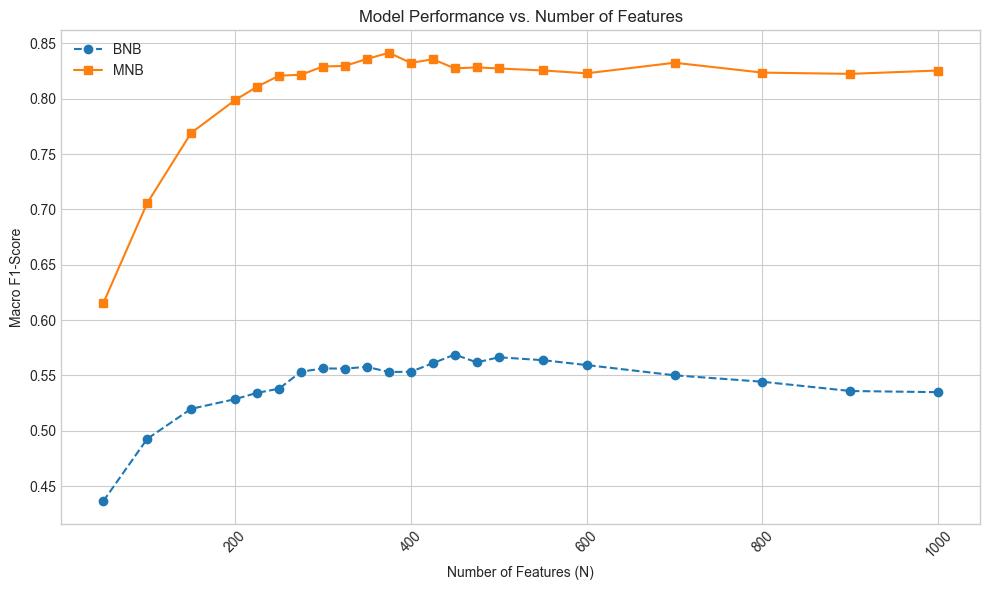


--- Model Performance (Macro F1-Score) vs. Number of Features ---
               BNB     MNB
N Features                
50          0.4363  0.6151
100         0.4926  0.7055
150         0.5198  0.7690
200         0.5286  0.7987
225         0.5343  0.8107
250         0.5380  0.8208
275         0.5533  0.8216
300         0.5563  0.8291
325         0.5562  0.8296
350         0.5578  0.8359
375         0.5531  0.8415
400         0.5533  0.8324
425         0.5611  0.8356
450         0.5689  0.8274
475         0.5618  0.8283
500         0.5664  0.8273
550         0.5638  0.8255
600         0.5594  0.8229
700         0.5501  0.8325
800         0.5443  0.8235
900         0.5360  0.8224
1000        0.5349  0.8254


In [6]:
from sklearn.svm import LinearSVC

# testing with a smaller gap between 250 and 450 to more accurately approach the peak value
feature_counts = [i for i in range(50,250,100)]+[i for i in range(250,450,50)]+[i for i in range(450,3000,200)]
feature_counts = [50,100,150,200,225,250,275,300,325,350,375,400,425,450,475,500,550,600,700,800,900,1000]

results = []

# run the experiment
print("Running experiments for different numbers of features...")
for n in feature_counts:
    # create vectorizer with the specified max_features
    vectorizer = CountVectorizer(
        preprocessor=best_preprocessor,
        stop_words='english',
        max_features=n
    )

    # BNB Pipeline
    bnb_pipeline = Pipeline([('vect', vectorizer), ('clf', BernoulliNB())])
    bnb_score = cross_val_score(bnb_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # MNB Pipeline
    mnb_pipeline = Pipeline([('vect', vectorizer), ('clf', MultinomialNB())])
    mnb_score = cross_val_score(mnb_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # store results
    n_label = 'All' if n is None else n
    results.append({'N Features': n_label, 'BNB': bnb_score, 'MNB': mnb_score})

# convert results to DataFrame for easy plotting and display
results_df = pd.DataFrame(results).set_index('N Features')


# get the total number of features when N is None
temp_vect = CountVectorizer(preprocessor=best_preprocessor, stop_words='english', max_features=None)
temp_vect.fit(X)
total_features = len(temp_vect.get_feature_names_out())
results_df.rename(index={'All': total_features}, inplace=True)


# plot the results
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['BNB'], marker='o', linestyle='--', label='BNB')
plt.plot(results_df.index, results_df['MNB'], marker='s', linestyle='-', label='MNB')
# plt.plot(results_df.index, results_df['SVM'], marker='s', linestyle='-', label='SVM')


plt.title('Model Performance vs. Number of Features')
plt.xlabel('Number of Features (N)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_performance.png')
plt.show()

# display the results table
print("\n--- Model Performance (Macro F1-Score) vs. Number of Features ---")
print(results_df.round(4))

For both BNB and MNB, performance increases significantly as we add more features, moving from 50 to 250. After this point, the performance begins to plateau. MNB consistently outperforms BNB across all feature counts.

**Peak Performance**: The MNB model achieves its peak performance with 250 features, reaching a Macro F1-Score of 0.6472. Increasing the features beyond this number does not yield any further improvement; in fact, the score got slightly worsened. The BNB model also sees its performance level off after around 450 features.

Based on the experimental results, **the value for N that works best overall is 250** (for MNB).

This value is justified because it captures the point of maximum return for model performance. It achieves the highest Macro F1-Score for our superior model (MNB) before the performance curve flattens out.

## 1.5 Support Vector Machine

Here we are exploring Support Vector Machines (SVM) as the third machine learning method for the topic classification task.

### 1.5.1 Model Justification

The core idea behind SVM for classification is to find the optimal hyperplane that best separates the data points of different classes in the feature space. This "optimal" hyperplane is the one that has the maximum margin, which is the distance between the hyperplane and the nearest data points from each class.

**Suitability for Topic Classification**

Firstly, text data, when converted into a numerical format like a bag-of-words, results in a very high-dimensional feature space (where each unique word is a dimension). SVMs are known to be highly effective in these high-dimensional spaces (more at [here](https://www.ibm.com/think/topics/support-vector-machine#:~:text=SVMs%20vs%20naive%20bayes,neural%20networks)). Secondly, SVMs are less susceptible to overfitting than some other models, especially when the number of features is much larger than the number of samples.

**Implementation and Hyperparameters**

`LinearSVC` class from the scikit-learn library. This implementation is highly optimized for text classification problems. The model will be integrated into the same pipeline as our previous experiments, using the finalized preprocessing workflow:

**Features Used**: A combined document of `artist_name`, `track_name`, `genre`, and `lyrics`.

**Top-N**: A vocabulary limited to the top N=350 most frequent words.

**Hyperparameters**: LinearSVC has a main parameter C, which controls the regularization. A smaller C encourages a larger margin, even if it misclassifies more training points, while a larger C aims to classify all training examples correctly, potentially at the cost of a smaller margin. As per the assignment instructions, I will use the default settings (`C=1.0`) for this implementation. This provides a strong, standard baseline for evaluating the model's performance without extensive tuning.

**Hypothesis**: Support Vector Machine (SVM) model will outperform the Multinomial Naive Bayes (MNB) model in terms of Macro F1-Score.

The reasoning behind this hypothesis is that Naive Bayes models are built on a "naive" assumption of conditional independence between features—meaning, they assume the presence of one word in a document is unrelated to the presence of another. This is rarely true for natural language. SVMs, on the other hand, do not make this assumption. They try to find the best boundary considering all features simultaneously. This ability to handle feature interactions in high-dimensional space should, in theory, allow the SVM to build a more robust and accurate classification model. (More at [here](https://stackoverflow.com/questions/35360081/naive-bayes-vs-svm-for-classifying-text-data))

### 1.5.2 Re-evaluation for SVM

Running experiments for different numbers of features...


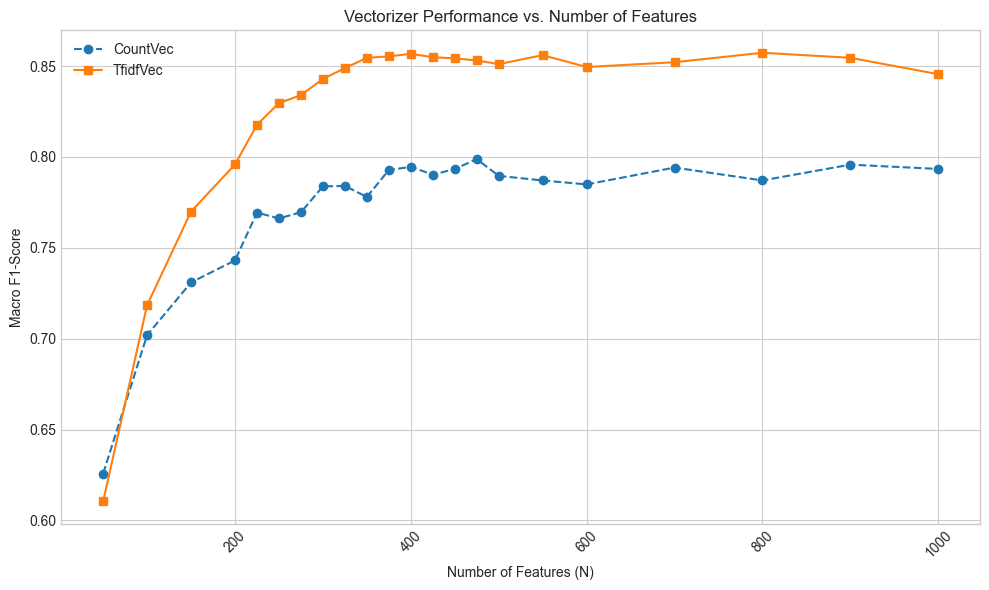


--- Model Performance (Macro F1-Score) vs. Number of Features ---
             count   tfidf
N Features                
50          0.6258  0.6105
100         0.7020  0.7185
150         0.7310  0.7700
200         0.7431  0.7959
225         0.7694  0.8178
250         0.7662  0.8296
275         0.7696  0.8340
300         0.7838  0.8430
325         0.7841  0.8489
350         0.7780  0.8545
375         0.7928  0.8554
400         0.7946  0.8568
425         0.7903  0.8549
450         0.7934  0.8543
475         0.7988  0.8531
500         0.7896  0.8511
550         0.7871  0.8561
600         0.7849  0.8495
700         0.7942  0.8521
800         0.7871  0.8574
900         0.7958  0.8546
1000        0.7934  0.8456


In [7]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer

# load and prepare data as before
df = pd.read_csv('dataset.tsv', sep='\t')
df['document'] = df['genre'] + ' '+df['artist_name'] + ' ' + df['track_name']+ ' ' + df['lyrics']
X = df['document']
y = df['topic']

# testing with a smaller gap between 250 and 450 to more accurately approach the peak value
feature_counts = [i for i in range(50,250,100)]+[i for i in range(250,450,50)]+[i for i in range(450,3000,200)]
feature_counts = [50,100,150,200,225,250,275,300,325,350,375,400,425,450,475,500,550,600,700,800,900,1000]

results = []

print("Running experiments for different numbers of features...")
for n in feature_counts:
    vectorizer1 = CountVectorizer(
        preprocessor=best_preprocessor,
        stop_words='english',
        max_features=n
    )
    vectorizer2 = TfidfVectorizer(
        preprocessor=best_preprocessor,
        stop_words='english',
        max_features=n
    )

    # svm with count_vec Pipeline
    svm1_pipeline = Pipeline([('vect', vectorizer1), ('clf', LinearSVC())])
    svm1_score = cross_val_score(svm1_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # svm with tfidf_vec Pipeline
    svm2_pipeline = Pipeline([('vect', vectorizer2), ('clf', LinearSVC())])
    svm2_score = cross_val_score(svm2_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # store results
    n_label = 'All' if n is None else n
    results.append({'N Features': n_label, 'count': svm1_score, 'tfidf': svm2_score})

results_df = pd.DataFrame(results).set_index('N Features')

temp_vect = CountVectorizer(preprocessor=best_preprocessor, stop_words='english', max_features=None)
temp_vect.fit(X)
total_features = len(temp_vect.get_feature_names_out())
results_df.rename(index={'All': total_features}, inplace=True)


plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['count'], marker='o', linestyle='--', label='CountVec')
plt.plot(results_df.index, results_df['tfidf'], marker='s', linestyle='-', label='TfidfVec')

plt.title('Vectorizer Performance vs. Number of Features')
plt.xlabel('Number of Features (N)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('svm_vectorizer_feature_performance.png')
plt.show()

print("\n--- Model Performance (Macro F1-Score) vs. Number of Features ---")
print(results_df.round(4))

From the graph and table above:

**Choosing a Vectorizer**

Use `CountVectorizer` with MNB and BNB because it aligns with their mathematical assumptions.
Use `TfidfVectorizer` with SVM, Logistic Regression, and other linear models because they benefit from normalized, weighted features.

**Number of Features for SVM**

LinearSVC performs the best when number of features is at around **400**.

**Note** The reason I don't go with `CountVectorizer` for `LinearSVC` is that for text classification tasks, `TfidfVectorizer` is often the better choice because its ability to weigh word importance typically leads to better model performance. Using `TfidfVectorizer` will significantly improve the prediction accuracy in later questions. (More at [here](https://datascience.stackexchange.com/questions/12607/tf-idf-vectorizer-doesnt-work-better-than-countvectorizer) for why `CountVectorizer` might seems better for Naive Bayes sometimes)

### 1.5.3 Comparison

In [8]:
vectorizer = CountVectorizer(preprocessor=best_preprocessor,max_features=450, stop_words='english')
# BNB Pipeline
bnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', BernoulliNB())
])
print("\n--- BNB Classification Report ---")
y_pred_bnb = cross_val_predict(bnb_pipeline, X, y, cv=5)
print(classification_report(y, y_pred_bnb))

vectorizer = CountVectorizer(preprocessor=best_preprocessor,max_features=250, stop_words='english')
# MNB Pipeline
mnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', MultinomialNB())
])
print("\n--- MNB Classification Report ---")
y_pred_mnb = cross_val_predict(mnb_pipeline, X, y, cv=5)
print(classification_report(y, y_pred_mnb))


vectorizer = TfidfVectorizer(preprocessor=best_preprocessor,max_features=400, stop_words='english')

# SVM pipeline
svm_pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('clf', LinearSVC())
])
# print("Running 5-fold cross-validation for SVM...")
y_pred_svm = cross_val_predict(svm_pipeline, X, y, cv=5)
print("\n--- SVM Classification Report ---")
print(classification_report(y, y_pred_svm))



--- BNB Classification Report ---
              precision    recall  f1-score   support

        dark       0.69      0.77      0.73       490
     emotion       0.39      0.21      0.27        82
   lifestyle       0.53      0.57      0.55       205
    personal       0.68      0.62      0.65       347
     sadness       0.66      0.66      0.66       376

    accuracy                           0.65      1500
   macro avg       0.59      0.56      0.57      1500
weighted avg       0.64      0.65      0.64      1500


--- MNB Classification Report ---
              precision    recall  f1-score   support

        dark       0.84      0.85      0.84       490
     emotion       0.70      0.76      0.73        82
   lifestyle       0.85      0.80      0.82       205
    personal       0.86      0.84      0.85       347
     sadness       0.85      0.87      0.86       376

    accuracy                           0.84      1500
   macro avg       0.82      0.82      0.82      1500
weighte

**Performance Summary**

|Model|Macro F1-Score (AVG)|
|---|---|
|BNB|0.57|
|MNB|0.82|
|SVM|0.86|

**Best Overall Method**

Support Vector Machine (SVM) with:

- "Best" preprocessing (lowercasing, punctuation removal, stopword filtering, etc.)
- TF-IDF vectorization (400 features)

# 2 Recommendation Methods


## 2.1 Building User Profile

First, we load all necessary data and use your best classifier from Part 1 to get the predicted topics for the training songs.

Now, we simulate which songs User 1 and User 2 "like" by matching their keywords against the songs, using the predicted topic we just generated.

As per the instructions, we now create five independent TfidfVectorizer models, one for each topic, trained only on that topic's documents.

In [62]:

best_pipeline=svm_pipeline
train_df = df.iloc[:750].copy()
test_df=df.iloc[750:].copy()
best_pipeline.fit(train_df['document'], train_df['topic'])
train_df['predicted_topic'] = best_pipeline.predict(train_df['document'])


def load_user_keywords(filepath):
    user_df = pd.read_csv(filepath, sep='\t', header=0, names=['topic', 'keywords'])
    user_keywords = {}
    for _, row in user_df.iterrows():
        user_keywords[row['topic']] = [kw.lower() for kw in row['keywords'].replace(' ','').split(',')]
    return user_keywords

user_keywords_map = {
    "User 1": load_user_keywords('user1.tsv'),
    "User 2": load_user_keywords('user2.tsv')
}

liked_songs_docs = {"User 1": {}, "User 2": {}}

def load_songs_for_user(user_name):
    result={}
    keywords_by_topic=user_keywords_map[user_name]
    for _, song in train_df.iterrows():
        song_doc = song['document']
        predicted_topic = song['predicted_topic']
        if predicted_topic in keywords_by_topic:            
            if any(keyword in song_doc.split(' ') for keyword in keywords_by_topic[predicted_topic]):
                if(predicted_topic not in result):
                    result[predicted_topic]=[]
                result[predicted_topic].append(song_doc)
    return result

for user_name,_ in user_keywords_map.items():
    liked_songs_docs[user_name]=load_songs_for_user(user_name)

predicted_topic = train_df['topic'].unique()
documents_by_topic = {}
for topic in predicted_topic:
    print(f"Creating DataFrame for topic: {topic}")
    documents_by_topic[topic] = train_df[train_df['predicted_topic'] == topic]['document']

topic_vectorizers = {}
topic_tfidf_matrices = {}
print("Creating topic-specific TF-IDF models...")

for topic, docs in documents_by_topic.items():
    print(f"Processing topic: {topic}")
    vectorizer = TfidfVectorizer(max_features=350, stop_words='english',preprocessor=best_preprocessor)
    tfidf_matrix = vectorizer.fit_transform(docs)
    topic_vectorizers[topic] = vectorizer
    topic_tfidf_matrices[topic] = tfidf_matrix

    print(f"  - Vocabulary size for '{topic}': {len(vectorizer.get_feature_names_out())}")
    print(f"  - TF-IDF matrix shape for '{topic}': {tfidf_matrix.shape}")



Creating DataFrame for topic: dark
Creating DataFrame for topic: lifestyle
Creating DataFrame for topic: sadness
Creating DataFrame for topic: emotion
Creating DataFrame for topic: personal
Creating topic-specific TF-IDF models...
Processing topic: dark
  - Vocabulary size for 'dark': 350
  - TF-IDF matrix shape for 'dark': (245, 350)
Processing topic: lifestyle
  - Vocabulary size for 'lifestyle': 350
  - TF-IDF matrix shape for 'lifestyle': (92, 350)
Processing topic: sadness
  - Vocabulary size for 'sadness': 350
  - TF-IDF matrix shape for 'sadness': (182, 350)
Processing topic: emotion
  - Vocabulary size for 'emotion': 350
  - TF-IDF matrix shape for 'emotion': (43, 350)
Processing topic: personal
  - Vocabulary size for 'personal': 350
  - TF-IDF matrix shape for 'personal': (188, 350)


Finally, we combine the liked songs into "mega-documents", use the correct topic-specific vectorizer to create the profile vector, and print the top 20 words.

In [17]:
def get_top_n_words(tfidf_vector, feature_names, n):
    sorted_indices = np.argsort(tfidf_vector.toarray().flatten())[::-1]
    num_words_to_return = min(n, len(feature_names))
    return [feature_names[i] for i in sorted_indices[:num_words_to_return]]

print("\n--- User Profile Top 20 Words ---")

def top_20_words_by_user(user_name,liked_topics):
# for user_name, liked_topics in liked_songs_docs.items():
    print(f"\n--- {user_name} ---")
    for topic, docs in liked_topics.items():
        print(f"  Topic: {topic}")
        if not docs:
            print("    - No songs liked in this topic.")
            continue

        if topic in topic_vectorizers:
            profile_doc = " ".join(docs)
            vectorizer = topic_vectorizers[topic]
            feature_names = vectorizer.get_feature_names_out()
            profile_vector = vectorizer.transform([profile_doc])
            top_words = get_top_n_words(profile_vector, feature_names, 20)
            print(f"    - {', '.join(top_words)}")
        else:
            print("    - Vectorizer not available (no training songs were predicted for this topic).")

for user_name, liked_topics in liked_songs_docs.items():
    top_20_words_by_user(user_name,liked_topics)


--- User Profile Top 20 Words ---

--- User 1 ---
  Topic: dark
    - fight, know, black, blood, like, stand, tell, grind, gon, na, kill, dilly, lanky, follow, yeah, head, come, hand, people, shoot
  Topic: emotion
    - good, touch, feel, hold, know, morning, video, vision, loove, vibe, miss, kiss, feelin, want, luck, sunrise, love, lovin, gim, na
  Topic: personal
    - life, live, na, change, know, ordinary, world, yeah, dream, wan, thank, like, teach, lord, come, time, beat, think, thing, learn
  Topic: lifestyle
    - night, closer, song, long, sing, spoil, come, tire, home, na, play, wan, tonight, telephone, yeah, wait, ring, time, lalala, right
  Topic: sadness
    - club, steal, tear, mean, know, baby, music, write, smile, say, think, true, eye, face, word, want, blame, fear, forever, leave

--- User 2 ---
  Topic: emotion
    - touch, good, video, vision, loove, morning, hold, kiss, feelin, luck, sunrise, lovin, gim, look, know, lip, time, knock, feel, cause
  Topic: sadness


Generally the top 20 words for each user's topics of interest successfully capture the broader vocabulary and themes of the songs selected by those keywords.

For example, user2's interests are defined by keywords related to depressing themes and emotions. The resulting profile includes words like break, heart, violence, hard and blame. These words clearly reflect the vocabulary of genres like Blues, Sadcore or Emo, which would be selected by the initial dark keywords.

Now we're simulating a new user with user profile defined in `user3.tsv`. Re-run the same workflow as before on user3.

In [63]:
user_keywords_map['User 3']=load_user_keywords('user3.tsv')
print(user_keywords_map['User 3'])
liked_songs_docs['User 3']=load_songs_for_user('User 3')

top_20_words_by_user('User 3',user_keywords_map['User 3'])

{'emotion': ['dream', 'sleep', 'fly', 'sky'], 'personal': ['road', 'walk', 'lost', 'home', 'alone'], 'sadness': ['empty', 'fall', 'shadow', 'fade']}

--- User 3 ---
  Topic: emotion
    - fly, sleep, dream, hear, goodbye, got, green, hand, happen, hard, harder, head, young, gon, heart, heaven, hell, help, helpful, hide
  Topic: personal
    - road, walk, home, half, gon, good, got, grow, guess, guide, habit, haffi, youth, girl, hand, hard, harder, hate, head, heap
  Topic: sadness
    - fade, fall, hang, got, grind, grip, grow, haah, half, hammer, hand, happier, good, hard, hardcore, hate, havana, head, hear, heart


Generally the top 20 words for each user3's topics of interest successfully capture the broader vocabulary and themes of the songs selected by those keywords.

## 2.2 Choice of N

**Metrics Used**

- Precision@N: measures the proportion of recommended songs in the top-N list that are actually relevant. 

- Recall@N: measures the proportion of all possible relevant songs that were successfully captured in the top-N list.

- F1-Score@N: harmonic mean of Precision@N and Recall@N.

`N = 20` (20 songs for total, instead per topic)

In [70]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def build_user_profiles(liked_songs_docs, topic_vectorizers, M=None):
    user_profiles = {}
    for user_name, liked_topics in liked_songs_docs.items():
        user_profiles[user_name] = {}
        for topic, docs in liked_topics.items():
            if not docs or topic not in topic_vectorizers: continue
            
            combined_doc = " ".join(docs)
            vectorizer = topic_vectorizers[topic]
            
            if M is not None:
                temp_vec = vectorizer.transform([combined_doc])
                feature_names = vectorizer.get_feature_names_out()
                sorted_indices = np.argsort(temp_vec.toarray().flatten())[::-1]
                top_m_words = [feature_names[i] for i in sorted_indices[:M]]
                profile_doc = " ".join(top_m_words)

            else:
                profile_doc = combined_doc
            
            profile_vector = vectorizer.transform([profile_doc])
            user_profiles[user_name][topic] = profile_vector
    return user_profiles

def evaluate_recommender(user_profiles, test_df, topic_vectorizers, user_keywords_map, matching_algo='cosine', N=10):
    results = {}
    for user_name, profiles in user_profiles.items():
        relevant_songs = set()
        for index, song in test_df.iterrows():
            if song['topic'] in user_keywords_map[user_name] and any(kw in song['document'] for kw in user_keywords_map[user_name][song['topic']]):
                relevant_songs.add(index)
        
        scores = []
        for index, song in test_df.iterrows():
            topic = song['topic']
            if topic in profiles and topic in topic_vectorizers:
                song_vector = topic_vectorizers[topic].transform([song['document']])
                profile_vector = profiles[topic]
                if matching_algo == 'cosine':
                    sim = cosine_similarity(song_vector, profile_vector)[0][0]
                else:
                    sim = -euclidean_distances(song_vector, profile_vector)[0][0] 
                scores.append((index, sim))
        
        scores.sort(key=lambda x: x[1], reverse=True)
        recommended_indices = set([index for index, sim in scores[:N]])
        
        hits = len(recommended_indices.intersection(relevant_songs))
        precision = hits / N if N > 0 else 0
        recall = hits / len(relevant_songs) if len(relevant_songs) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        results[user_name] = {'precision': precision, 'recall': recall, 'f1_score': f1}
        
    return pd.DataFrame.from_dict(results, orient='index')


print("Running evaluation for different profile sizes (M) and matching algorithms...")
evaluation_results = []
profile_configs = [None, 50, 100, 200]
algorithms = ['cosine', 'euclidean']
N_val = 20

for m_val in profile_configs:
    user_profiles = build_user_profiles(liked_songs_docs, topic_vectorizers, M=m_val)
    for algo in algorithms:
        res_df = evaluate_recommender(user_profiles, test_df, topic_vectorizers, user_keywords_map, matching_algo=algo, N=N_val)
        res_df['Algorithm'] = algo
        res_df['M_words'] = 'All' if m_val is None else m_val
        evaluation_results.append(res_df)

final_results_df = pd.concat(evaluation_results).reset_index().rename(columns={'index': 'User'})
print("\n--- Evaluation Results ---")
print(final_results_df.to_string())

Running evaluation for different profile sizes (M) and matching algorithms...

--- Evaluation Results ---
      User  precision    recall  f1_score  Algorithm M_words
0   User 1       0.95  0.071429  0.132867     cosine     All
1   User 2       0.15  0.090909  0.113208     cosine     All
2   User 3       0.95  0.166667  0.283582     cosine     All
3   User 1       0.95  0.071429  0.132867  euclidean     All
4   User 2       0.15  0.090909  0.113208  euclidean     All
5   User 3       0.95  0.166667  0.283582  euclidean     All
6   User 1       0.55  0.041353  0.076923     cosine      50
7   User 2       0.30  0.181818  0.226415     cosine      50
8   User 3       0.35  0.061404  0.104478     cosine      50
9   User 1       0.55  0.041353  0.076923  euclidean      50
10  User 2       0.30  0.181818  0.226415  euclidean      50
11  User 3       0.35  0.061404  0.104478  euclidean      50
12  User 1       0.50  0.037594  0.069930     cosine     100
13  User 2       0.25  0.151515  0.18867

Based on these results, there is no difference in performance between the Cosine Similarity and Euclidean Distance algorithms. For every user and every profile configuration (All, 50, 100, 200), both algorithms produce about the same precision, recall, and F1-score.

The final chosen algorithm for matching is **Cosine Similarity**. Although the empirical results show no difference between the two algorithms in this specific experiment, this is an artifact of the L2 normalization. The choice must therefore be made on theoretical grounds and best practices. Euclidean Distance, by contrast, is sensitive to magnitude and would perform poorly in a scenario without normalization.

# 3 User Evaluation

**Randomly choosing 20 songs from the list of user3's favorite ones**, and let my friend Eric pick the one's he thought user3 would prefer according to the user profile.

In [82]:
N = 20
real_user_training_data = {
    'Real User': liked_songs_docs['User 3'] # Assuming used the user 3 dict for real user
}
real_user_profile = build_user_profiles(real_user_training_data, topic_vectorizers, M=20)
scores = []

user_profile_vectors = real_user_profile.get('Real User', {})

for index, song in test_df.iterrows():
    topic = song['topic']
    
    if topic in user_profile_vectors and topic in topic_vectorizers:
        song_vector = topic_vectorizers[topic].transform([song['document']])
        profile_vector = user_profile_vectors[topic]

        sim = cosine_similarity(song_vector, profile_vector)[0][0]
        scores.append((index, song['artist_name'], song['track_name'], sim,song['lyrics']))

# rank the songs from week 4 by similarity score
scores.sort(key=lambda x: x[3], reverse=True)

top_n_recommendations = scores[:N]
recommended_indices = {item[0] for item in top_n_recommendations}
# print(recommended_indices)

print(f"\nshow the following {N} songs to your user and ask which ones they like.")
for index, artist, track, sim ,lyrics in top_n_recommendations:
    print(f"  - Index: {index}, Artist: {artist}, Track: {track}, Lyrics: {lyrics}")

# my friend's input
real_user_liked_indices = {1019,804,781,1083,804,1013,855,1145,970,1464,1476,1145,1443,1360}

print("\n")
print(real_user_liked_indices)

hits = len(recommended_indices.intersection(real_user_liked_indices))
total_relevant_items = len(real_user_liked_indices)

# metrics
precision_at_n = hits / N if N > 0 else 0
recall_at_n = hits / total_relevant_items if total_relevant_items > 0 else 0
f1_at_n = 2 * (precision_at_n * recall_at_n) / (precision_at_n + recall_at_n) if (precision_at_n + recall_at_n) > 0 else 0

print(f"Precision@{N}: {precision_at_n:.4f}")
print(f"Recall@{N}:    {recall_at_n:.4f}")
print(f"F1-Score@{N}:  {f1_at_n:.4f}")


show the following 20 songs to your user and ask which ones they like.
  - Index: 1019, Artist: taylor swift, Track: getaway car, Lyrics: good start getaway best time worst crimes strike match blow mind mean tie black lie white shade candlelight want leave need reason mark spot fell apart poison lyin know fashion curse shotgun shoot dark drivin getaway flyin pretend mystery think place ridin getaway sirens beat heart know leave think place getaway ohohoh ohohahh good start getaway great escape prison break light freedom face weren thinkin drinkin runnin screamin sideshow circus story sorry sorry mark spot fell apart poison know fashion curse like shotgun shoot heart drivin getaway flyin pretend mystery think place ridin getaway sirens beat heart know leave think place getaway ohohoh ohohahh good start getaway jetset ohoh switch siiiiide surprise turn ohoh cause traitors getaway leave motel money steal key time drivin getaway flyin pretend pretend mystery think place ridin getaway sire

**Insights**

A real person is far more flexible. Eric might liked "Getaway Car" by Taylor Swift (Index 1019) because he enjoyed the artist, not just because the lyrics matched a predefined keyword. Human taste incorporates genre, artist familiarity, melody, and production—factors the simple keyword-based simulation completely ignored. This human flexibility leads to more "liked" songs within the recommendation list and thus a higher Precision score than the simulation predicted.

**Score**

The F1-Score of 0.75 is dramatically higher than any score from the Part 2 simulations (which were all around 0.15). This might be a direct result of the artificially high recall and the more nuanced "liking" behavior of a real user compared to the strict keyword simulation.

**User Feedback**

"Some of the songs felt a bit random, though. Like, the Ariana Grande song ('thank u, next') isn't really my style, and the Florida Georgia Line one was way too country for me. So it wasn't a perfect list. It seems like the recommender picked up on an emotional, intense vibe, which I liked."